In [ ]:
import os

print(" Searching for CSV files in your Drive...")

matches = []
for root, dirs, files in os.walk("/content/drive", topdown=True):
    for f in files:
        if f.lower().endswith(".csv") and "diab" in f.lower():
            matches.append(os.path.join(root, f))

matches[:10]


 Searching for CSV files in your Drive...


[]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

csv_path = "/content/drive/MyDrive/TongueImagediabetes/clinical/diabetes_prediction_dataset (2).csv"
df = pd.read_csv(csv_path)

df.head(), df.info()


Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              10000 non-null  float64
 1   bmi              10000 non-null  float64
 2   gender           10000 non-null  object 
 3   smoking_history  10000 non-null  object 
 4   hypertension     10000 non-null  int64  
 5   heart_disease    10000 non-null  int64  
 6   diabetes         10000 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 547.0+ KB


(    age    bmi  gender smoking_history  hypertension  heart_disease  diabetes
 0  80.0  34.65  female           never             0              0         1
 1  56.0  33.30  female           never             0              0         0
 2  44.0  24.31    male         current             0              0         0
 3  31.0  28.92    male          former             0              0         0
 4  66.0  29.95  female           never             1              0         0,
 None)

In [ ]:
from sklearn.model_selection import train_test_split

# target column
y = df["diabetes"]
X = df.drop(columns=["diabetes"])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Train: (7000, 6)
Val:   (1500, 6)
Test:  (1500, 6)


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = ['age', 'bmi', 'hypertension', 'heart_disease']
categorical_features = ['gender', 'smoking_history']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])


In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)
import numpy as np

clf.fit(X_train, y_train)

def eval_split(name, Xs, ys):
    probs = clf.predict_proba(Xs)[:, 1]
    preds = (probs >= 0.5).astype(int)

    auroc = roc_auc_score(ys, probs)
    auprc = average_precision_score(ys, probs)
    print(f"\n=== {name} ===")
    print(f"AUROC: {auroc:.4f}  AUPRC: {auprc:.4f}")
    print("Confusion matrix [tn fp; fn tp]:")
    print(confusion_matrix(ys, preds))
    print("\nClassification report:")
    print(classification_report(ys, preds, digits=3))

eval_split("VALIDATION", X_val, y_val)
eval_split("TEST", X_test, y_test)



=== VALIDATION ===
AUROC: 0.7945  AUPRC: 0.7721
Confusion matrix [tn fp; fn tp]:
[[512 238]
 [182 568]]

Classification report:
              precision    recall  f1-score   support

           0      0.738     0.683     0.709       750
           1      0.705     0.757     0.730       750

    accuracy                          0.720      1500
   macro avg      0.721     0.720     0.720      1500
weighted avg      0.721     0.720     0.720      1500


=== TEST ===
AUROC: 0.8064  AUPRC: 0.7785
Confusion matrix [tn fp; fn tp]:
[[509 241]
 [169 581]]

Classification report:
              precision    recall  f1-score   support

           0      0.751     0.679     0.713       750
           1      0.707     0.775     0.739       750

    accuracy                          0.727      1500
   macro avg      0.729     0.727     0.726      1500
weighted avg      0.729     0.727     0.726      1500



In [ ]:
import joblib, os

save_dir = "/content/drive/MyDrive/TongueImagediabetes/clinical"
os.makedirs(save_dir, exist_ok=True)

joblib_path = os.path.join(save_dir, "clinical_logreg_pipeline.joblib")
joblib.dump(clf, joblib_path)

print("Saved clinical model to:", joblib_path)


Saved clinical model to: /content/drive/MyDrive/TongueImagediabetes/clinical/clinical_logreg_pipeline.joblib


In [ ]:
!pip install xgboost


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

numeric_features = ['age', 'bmi', 'hypertension', 'heart_disease']
categorical_features = ['gender', 'smoking_history']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist"  # fast on CPU, good for Colab
)

xgb_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', xgb)
])


In [ ]:
# we need preprocessed arrays for early stopping
X_train_proc = preprocess.fit_transform(X_train)
X_val_proc   = preprocess.transform(X_val)

xgb.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)],
    early_stopping_rounds=30,
    verbose=False
)


TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [ ]:
xgb_clf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
import numpy as np

def eval_split(name, Xs, ys, model):
    probs = model.predict_proba(Xs)[:, 1]
    preds = (probs >= 0.5).astype(int)

    auroc = roc_auc_score(ys, probs)
    auprc = average_precision_score(ys, probs)
    print(f"\n=== {name} ===")
    print(f"AUROC: {auroc:.4f}  AUPRC: {auprc:.4f}")
    print("Confusion matrix [tn fp; fn tp]:")
    print(confusion_matrix(ys, preds))
    print("\nClassification report:")
    print(classification_report(ys, preds, digits=3))

print("XGBoost performance:")
eval_split("VALIDATION", X_val, y_val, xgb_clf)
eval_split("TEST", X_test, y_test, xgb_clf)


XGBoost performance:

=== VALIDATION ===
AUROC: 0.7931  AUPRC: 0.7664
Confusion matrix [tn fp; fn tp]:
[[512 238]
 [183 567]]

Classification report:
              precision    recall  f1-score   support

           0      0.737     0.683     0.709       750
           1      0.704     0.756     0.729       750

    accuracy                          0.719      1500
   macro avg      0.721     0.719     0.719      1500
weighted avg      0.721     0.719     0.719      1500


=== TEST ===
AUROC: 0.8082  AUPRC: 0.7768
Confusion matrix [tn fp; fn tp]:
[[515 235]
 [159 591]]

Classification report:
              precision    recall  f1-score   support

           0      0.764     0.687     0.723       750
           1      0.715     0.788     0.750       750

    accuracy                          0.737      1500
   macro avg      0.740     0.737     0.737      1500
weighted avg      0.740     0.737     0.737      1500



In [ ]:
import joblib, os

save_dir = "/content/drive/MyDrive/TongueImagediabetes/clinical"
os.makedirs(save_dir, exist_ok=True)

joblib_path = os.path.join(save_dir, "clinical_xgboost_pipeline.joblib")
joblib.dump(xgb_clf, joblib_path)

print("Saved XGBoost clinical model to:", joblib_path)


Saved XGBoost clinical model to: /content/drive/MyDrive/TongueImagediabetes/clinical/clinical_xgboost_pipeline.joblib


In [ ]:
numeric_features = ['age', 'bmi', 'hypertension', 'heart_disease']
categorical_features = ['gender', 'smoking_history']


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    class_weight='balanced_subsample',
    random_state=42
)

rf_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', rf)
])


In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import numpy as np

def eval_model(name, clf, X_train, y_train, X_val, y_val, X_test, y_test):
    print(f"\n===== {name} =====")
    clf.fit(X_train, y_train)

    def eval_split(split_name, Xs, ys):
        probs = clf.predict_proba(Xs)[:, 1]
        preds = (probs >= 0.5).astype(int)

        auroc = roc_auc_score(ys, probs)
        auprc = average_precision_score(ys, probs)
        print(f"\n--- {split_name} ---")
        print(f"AUROC: {auroc:.4f}  AUPRC: {auprc:.4f}")
        print("Confusion matrix [tn fp; fn tp]:")
        print(confusion_matrix(ys, preds))
        print(classification_report(ys, preds, digits=3))

    eval_split("VALIDATION", X_val, y_val)
    eval_split("TEST",       X_test, y_test)


In [ ]:
eval_model("Random Forest", rf_clf,
           X_train, y_train,
           X_val, y_val,
           X_test, y_test)



===== Random Forest =====

--- VALIDATION ---
AUROC: 0.7323  AUPRC: 0.7032
Confusion matrix [tn fp; fn tp]:
[[491 259]
 [240 510]]
              precision    recall  f1-score   support

           0      0.672     0.655     0.663       750
           1      0.663     0.680     0.671       750

    accuracy                          0.667      1500
   macro avg      0.667     0.667     0.667      1500
weighted avg      0.667     0.667     0.667      1500


--- TEST ---
AUROC: 0.7476  AUPRC: 0.7148
Confusion matrix [tn fp; fn tp]:
[[502 248]
 [220 530]]
              precision    recall  f1-score   support

           0      0.695     0.669     0.682       750
           1      0.681     0.707     0.694       750

    accuracy                          0.688      1500
   macro avg      0.688     0.688     0.688      1500
weighted avg      0.688     0.688     0.688      1500



In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['age', 'bmi', 'hypertension', 'heart_disease']
categorical_features = ['gender', 'smoking_history']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # two hidden layers: 64 → 32
    activation='relu',
    solver='adam',
    alpha=1e-3,          # L2 regularization
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=200,
    random_state=42
)

mlp_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', mlp)
])


In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import numpy as np

def eval_model(name, clf, X_train, y_train, X_val, y_val, X_test, y_test):
    print(f"\n===== {name} =====")
    clf.fit(X_train, y_train)

    def eval_split(split_name, Xs, ys):
        probs = clf.predict_proba(Xs)[:, 1]
        preds = (probs >= 0.5).astype(int)

        auroc = roc_auc_score(ys, probs)
        auprc = average_precision_score(ys, probs)
        print(f"\n--- {split_name} ---")
        print(f"AUROC: {auroc:.4f}  AUPRC: {auprc:.4f}")
        print("Confusion matrix [tn fp; fn tp]:")
        print(confusion_matrix(ys, preds))
        print(classification_report(ys, preds, digits=3))

    eval_split("VALIDATION", X_val, y_val)
    eval_split("TEST",       X_test, y_test)


In [ ]:
eval_model("MLP Neural Net", mlp_clf,
           X_train, y_train,
           X_val, y_val,
           X_test, y_test)



===== MLP Neural Net =====

--- VALIDATION ---
AUROC: 0.7836  AUPRC: 0.7505
Confusion matrix [tn fp; fn tp]:
[[523 227]
 [194 556]]
              precision    recall  f1-score   support

           0      0.729     0.697     0.713       750
           1      0.710     0.741     0.725       750

    accuracy                          0.719      1500
   macro avg      0.720     0.719     0.719      1500
weighted avg      0.720     0.719     0.719      1500


--- TEST ---
AUROC: 0.8004  AUPRC: 0.7815
Confusion matrix [tn fp; fn tp]:
[[532 218]
 [184 566]]
              precision    recall  f1-score   support

           0      0.743     0.709     0.726       750
           1      0.722     0.755     0.738       750

    accuracy                          0.732      1500
   macro avg      0.732     0.732     0.732      1500
weighted avg      0.732     0.732     0.732      1500



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Numeric columns used for histograms: ['age', 'bmi']


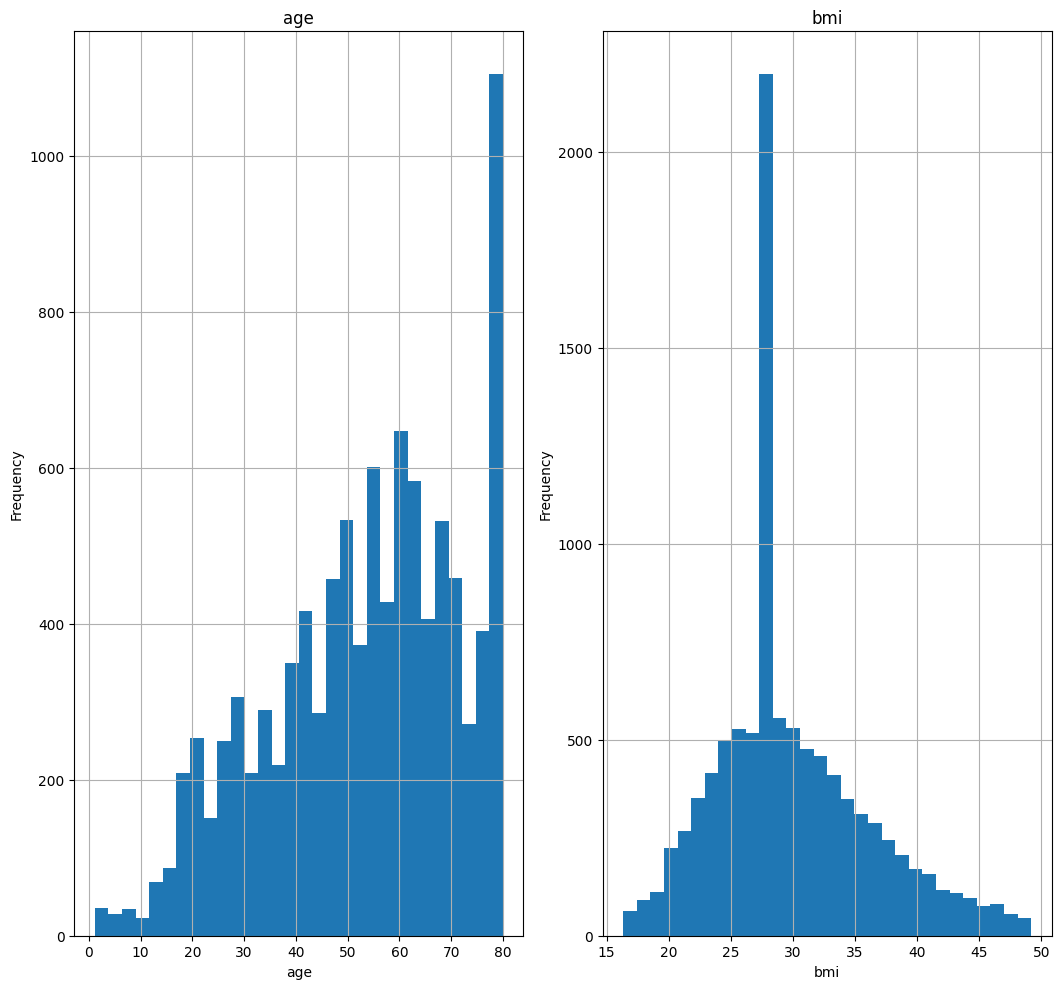

In [ ]:
import matplotlib.pyplot as plt

# Choose some important numeric columns
candidate_numeric = [
    'age', 'bmi', 'HbA1c_level', 'blood_glucose_level'
]

numeric_cols = [c for c in candidate_numeric if c in df.columns]

if not numeric_cols:
    # Fallback: auto-detect numeric columns
    numeric_cols = df.select_dtypes(include='number').columns.tolist()

print("Numeric columns used for histograms:", numeric_cols)

plt.figure(figsize=(16, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols) + 2) // 3, 3, i)
    df[col].hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

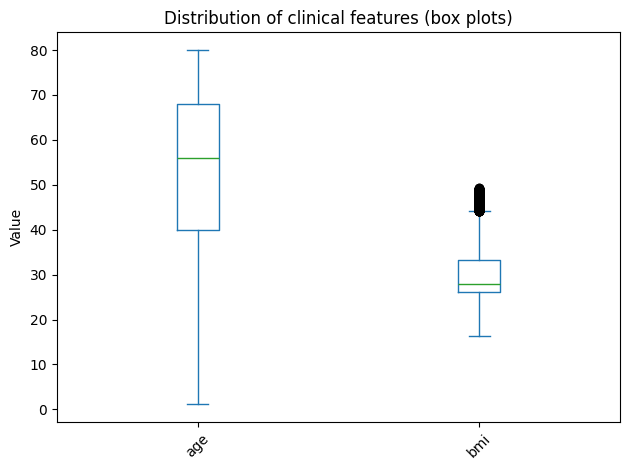

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df[numeric_cols].plot(kind='box')
plt.title("Distribution of clinical features (box plots)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


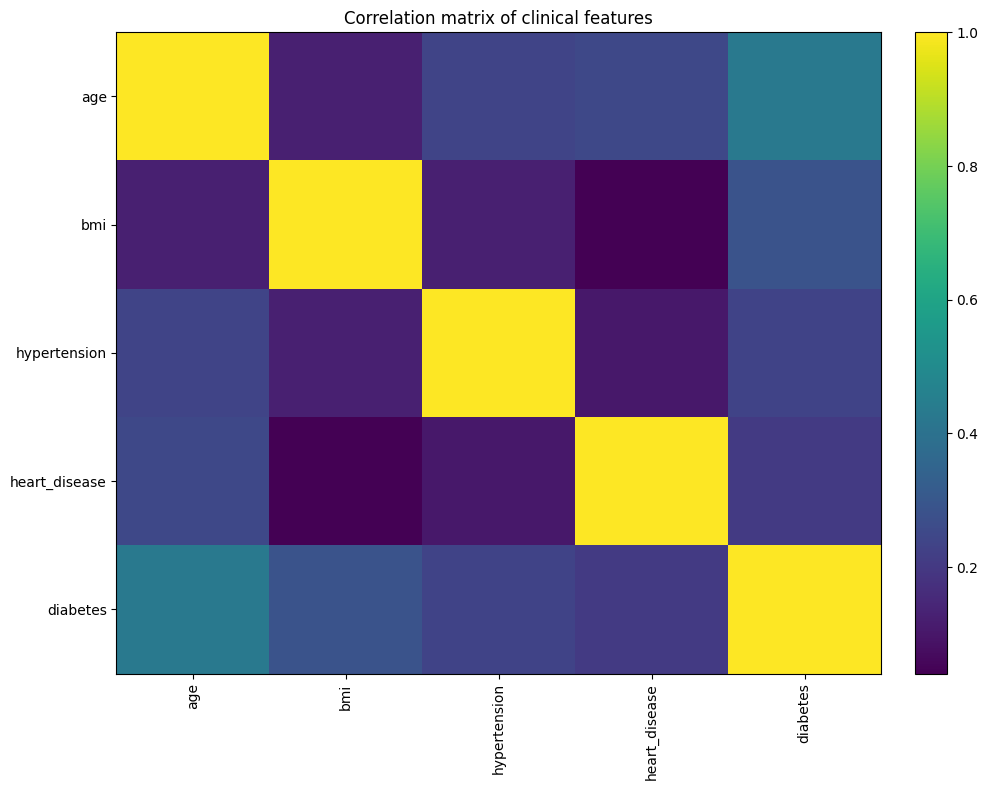

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick numeric columns again (you can restrict if it’s too many)
corr_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, aspect='auto')

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation matrix of clinical features")

plt.tight_layout()
plt.show()


/tmp/ipython-input-2677975337.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = df.groupby('age_band')[target_col].mean()


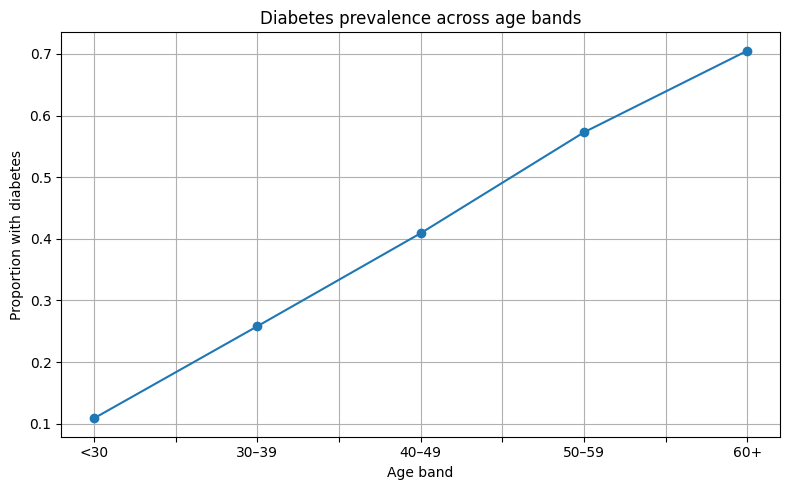

/tmp/ipython-input-2677975337.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_group_stats = df.groupby('bmi_band')[target_col].mean()


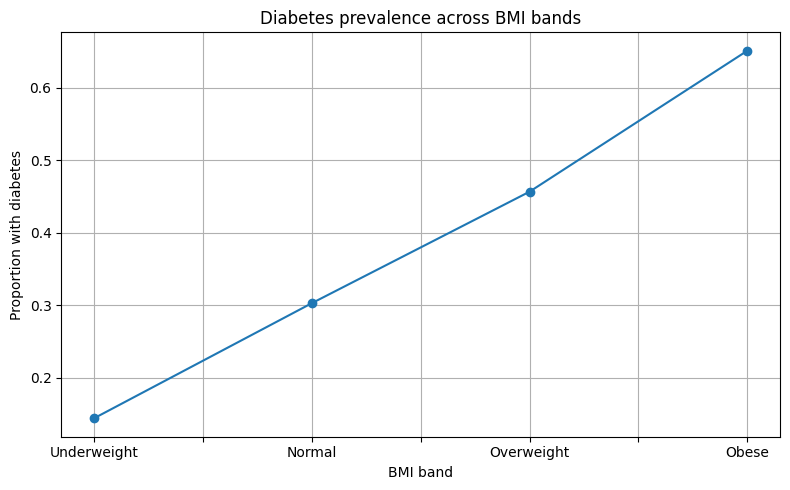

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the target column name matches your df
# Common names: 'diabetes', 'diabetes_dx', 'diabetes_binary'
target_col_candidates = ['diabetes', 'diabetes_binary', 'Outcome']
target_col = None
for c in target_col_candidates:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError("Could not find the diabetes target column. "
                     "Set target_col manually to your label column name.")

# Age bands
if 'age' in df.columns:
    df['age_band'] = pd.cut(df['age'],
                            bins=[0, 30, 40, 50, 60, 120],
                            labels=['<30', '30–39', '40–49', '50–59', '60+'])
else:
    raise ValueError("Column 'age' not found in df.")

# BMI bands (optional if bmi exists)
if 'bmi' in df.columns:
    df['bmi_band'] = pd.cut(df['bmi'],
                            bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Diabetes prevalence by age band
age_group_stats = df.groupby('age_band')[target_col].mean()

plt.figure(figsize=(8, 5))
age_group_stats.plot(kind='line', marker='o')
plt.title("Diabetes prevalence across age bands")
plt.xlabel("Age band")
plt.ylabel("Proportion with diabetes")
plt.grid(True)
plt.tight_layout()
plt.show()

# If BMI exists: prevalence by BMI band
if 'bmi_band' in df.columns:
    bmi_group_stats = df.groupby('bmi_band')[target_col].mean()

    plt.figure(figsize=(8, 5))
    bmi_group_stats.plot(kind='line', marker='o')
    plt.title("Diabetes prevalence across BMI bands")
    plt.xlabel("BMI band")
    plt.ylabel("Proportion with diabetes")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
